Code describtion

In [ ]:
"""
In this notebook, I create a CSV with historical SCADA data and upload it manually to LLM websites.
Use the following prompt:

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

You are an expert wind turbine power forecasting model.

You are given 14 days of historical SCADA data for ONE turbine.
The data is sampled every 10 minutes (144 rows per day).

Important: `Wspd` and `Patv` in the historical CSV are equal-width BIN IDs, not raw values.
- Number of bins: 16
- Valid bin IDs: integers from 0 to 15
- 0 = lowest range, 15 = highest range
- Predict in bin space only (do not convert to kW)

Task:
Predict the `Patv` bin for the NEXT 48 HOURS (288 time steps at 10-minute resolution).

Instructions:
1. Learn the relationship between `Wspd` bins and `Patv` bins from historical data.
2. Capture daily cyclic patterns.
3. Do NOT copy the last day.
4. Output only valid bin IDs (integers 0..15).

OUTPUT FORMAT REQUIREMENTS (VERY IMPORTANT):
- Output ONLY a CSV file.
- Exactly 289 rows (one header + 288 predictions).
- Exactly one column.
- Column header must be: Patv_pred
- Each value must be an integer in [0, 15].
- No explanations.
- No text before or after.
- No extra spaces.
- No commentary.

Correct output example:

Patv_pred
7
8
6
...

Historical data are attached.
Output format: Your output must be only ONE csv file.
"""

print("no code to run")



no code to run


Define functions

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------------
# 1) EXPORT 14-DAY INPUT CSV
# -----------------------------


from pathlib import Path
import pandas as pd

def export_llm_input_csv(
    data_csv: str,
    out_csv: str,
    turb_id: int,
    forecast_day: int,
    lookback_days: int = 14,
    cols=None,
):
    """
    Output CSV includes ALL original columns (same order as input) by default.
    """
    df = pd.read_csv(data_csv)

    # Use all columns from the original CSV (same order)
    if cols is None:
        cols = list(df.columns)

    hist_start = forecast_day - lookback_days
    hist_end = forecast_day - 1
    if hist_end < 1:
        raise ValueError("forecast_day is too small for the requested lookback_days.")

    # Basic required columns for filtering
    required = ["TurbID", "Day"]
    missing_req = [c for c in required if c not in df.columns]
    if missing_req:
        raise KeyError(f"Input CSV missing required columns: {missing_req}")

    turbine = df[df["TurbID"] == turb_id].copy()

    hist = turbine[(turbine["Day"] >= hist_start) & (turbine["Day"] <= hist_end)].copy()

    # Ensure all requested columns exist
    missing = [c for c in cols if c not in hist.columns]
    if missing:
        raise KeyError(f"Missing columns in dataset: {missing}")

    hist = hist[cols].copy()

    # Sort if possible
    sort_keys = [c for c in ["Day", "Tmstamp"] if c in hist.columns]
    if sort_keys:
        hist = hist.sort_values(sort_keys)

    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    hist.to_csv(out_csv, index=False)
    print(f"Saved LLM input CSV: {out_csv}")
    print(f"History days: {hist_start} .. {hist_end} | rows: {len(hist)}")
    return hist_start, hist_end


def export_llm_input_csv_equal_bins(
    data_csv: str,
    out_csv: str,
    turb_id: int,
    forecast_day: int,
    lookback_days: int = 14,
    cols=None,
    bin_cols=None,
    n_bins: int = 16,
):
    """
    Export history exactly like export_llm_input_csv, but convert selected
    numeric columns into equal-width (linear) bins.

    - Binned values are integer IDs in [0, n_bins-1].
    - By default, bin_cols uses numeric columns excluding TurbID/Day/Tmstamp.
    """
    if n_bins < 2:
        raise ValueError("n_bins must be >= 2.")

    df = pd.read_csv(data_csv)

    if cols is None:
        cols = list(df.columns)

    hist_start = forecast_day - lookback_days
    hist_end = forecast_day - 1
    if hist_end < 1:
        raise ValueError("forecast_day is too small for the requested lookback_days.")

    required = ["TurbID", "Day"]
    missing_req = [c for c in required if c not in df.columns]
    if missing_req:
        raise KeyError(f"Input CSV missing required columns: {missing_req}")

    turbine = df[df["TurbID"] == turb_id].copy()
    hist = turbine[(turbine["Day"] >= hist_start) & (turbine["Day"] <= hist_end)].copy()

    missing = [c for c in cols if c not in hist.columns]
    if missing:
        raise KeyError(f"Missing columns in dataset: {missing}")

    hist = hist[cols].copy()

    sort_keys = [c for c in ["Day", "Tmstamp"] if c in hist.columns]
    if sort_keys:
        hist = hist.sort_values(sort_keys)

    if bin_cols is None:
        excluded = {"TurbID", "Day", "Tmstamp"}
        bin_cols = [
            c for c in hist.columns
            if (c not in excluded) and pd.api.types.is_numeric_dtype(hist[c])
        ]

    missing_bin_cols = [c for c in bin_cols if c not in hist.columns]
    if missing_bin_cols:
        raise KeyError(f"bin_cols not found in selected data: {missing_bin_cols}")

    col_ranges = {}
    for c in bin_cols:
        x = pd.to_numeric(hist[c], errors="coerce")
        valid = x.dropna()

        if valid.empty:
            hist[c] = pd.Series(pd.NA, index=hist.index, dtype="Int64")
            continue

        lo = float(valid.min())
        hi = float(valid.max())
        col_ranges[c] = (lo, hi)

        if np.isclose(lo, hi):
            binned = pd.Series(pd.NA, index=hist.index, dtype="Int64")
            binned[x.notna()] = 0
            hist[c] = binned
            continue

        edges = np.linspace(lo, hi, n_bins + 1)
        binned = pd.cut(
            x,
            bins=edges,
            labels=False,
            include_lowest=True,
            duplicates="drop",
        )
        hist[c] = pd.Series(binned, index=hist.index).astype("Int64")

    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    hist.to_csv(out_csv, index=False)
    print(f"Saved binned LLM input CSV: {out_csv}")
    print(f"History days: {hist_start} .. {hist_end} | rows: {len(hist)}")
    print(f"Binned columns ({n_bins} equal-width bins): {list(bin_cols)}")
    for c in bin_cols:
        if c in col_ranges:
            lo, hi = col_ranges[c]
            print(f"  {c}: [{lo:.4f}, {hi:.4f}]")

    return hist_start, hist_end


def decode_patv_bins_csv(
    in_csv: str,
    out_csv: str,
):
    """
    Decode `Patv_pred` bin IDs to kW and save a new CSV.

    Notes:
    - Assumes 16 equal-width bins over Patv range [0, 1500] kW.
    - Uses bin center for decoding:
        patv_kw = min + (bin_id + 0.5) * (max - min) / n_bins
    - Keeps output header as `Patv_pred` for compatibility with evaluation code.
    """
    n_bins = 16
    patv_min = 0.0
    patv_max = 1500.0

    df = pd.read_csv(in_csv)

    if "Patv_pred" not in df.columns:
        raise KeyError("Input CSV must contain column 'Patv_pred'.")

    bins = pd.to_numeric(df["Patv_pred"], errors="coerce")

    # Clip to valid range in case the model emits out-of-range bins.
    bins = bins.clip(lower=0, upper=n_bins - 1)

    step = (patv_max - patv_min) / n_bins
    patv_kw = patv_min + (bins + 0.5) * step

    out = pd.DataFrame({"Patv_pred": patv_kw.round(2)})
    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(out_csv, index=False)

    print(f"Decoded bins CSV saved: {out_csv}")
    print(f"Rows: {len(out)} | Patv range used: [{patv_min}, {patv_max}] | bins: {n_bins}")
    return out


# -----------------------------
# 2) EVALUATE A MANUAL PREDICTION CSV
# -----------------------------
def evaluate_prediction_csv(
    data_csv: str,
    pred_csv: str,
    turb_id: int,
    forecast_day: int,
    horizon_days: int = 1,
    pred_col: str = "Patv_pred",
):
    

    import pandas as pd
    """
    Reads your model output CSV (made by the LLM) and computes MAE/RMSE vs ground truth.

    Expected prediction length:
      horizon_days=1 -> 144 values (Day forecast_day)
      horizon_days=2 -> 288 values (Day forecast_day and forecast_day+1)

    Prediction CSV formats supported:
      A) single column named pred_col (default Patv_pred) with 144 rows
      B) single column named 'Patv' with 144 rows
      C) one row with comma-separated values (144 numbers) in any first cell
    """
    df = pd.read_csv(data_csv)

    # Ground truth slice (do NOT dropna; keep alignment)
    target_days = list(range(forecast_day, forecast_day + horizon_days))
    actual_df = df[(df["TurbID"] == turb_id) & (
        df["Day"].isin(target_days))].copy()

    if "Tmstamp" in actual_df.columns:
        actual_df = actual_df.sort_values(["Day", "Tmstamp"])
    else:
        actual_df = actual_df.sort_values(["Day"])

    y_true = actual_df["Patv"].to_numpy(dtype=float)

    expected_len = 144 * horizon_days

    # Load prediction CSV
    pred_df = pd.read_csv(pred_csv)

    if pred_col in pred_df.columns:
        y_pred = pred_df[pred_col].to_numpy(dtype=float)
    elif "Patv" in pred_df.columns:
        y_pred = pred_df["Patv"].to_numpy(dtype=float)
    else:
        # Try to parse "one cell with comma-separated values"
        first_cell = str(pred_df.iloc[0, 0])
        parts = [p.strip() for p in first_cell.split(",") if p.strip()]
        y_pred = np.array([float(p) for p in parts], dtype=float)

    print(
        f"Expected: {expected_len} | Actual len: {len(y_true)} | Pred len: {len(y_pred)}")

    # Enforce expected length (recommended)
    if len(y_pred) != expected_len:
        raise ValueError(
            f"Prediction length is {len(y_pred)} but expected {expected_len}.")

    # Clip negatives to 0 (paper-style)
    y_true = np.maximum(y_true, 0.0)
    y_pred = np.maximum(y_pred, 0.0)

    # Cut actual to expected length (in case dataset has extra/missing rows)
    n = min(len(y_true), expected_len)
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    # Mask NaNs (if any)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    print(f"Used after NaN-mask: {len(y_true)} samples")

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    score = (mae+rmse)/2

    print(f"Mean Absolute Error: {mae:.2f} kW")
    print(f"Root Mean Square Error: {rmse:.2f} kW")
    print(f"Overall Score: {score:.2f} kW")
    #return mae, rmse



    import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_prediction_vs_ground_truth(
    data_csv: str,
    pred_csv: str,
    turb_id: int,
    forecast_day: int,
    horizon_days: int = 2,
    pred_col: str = "Patv_pred",
):
    df = pd.read_csv(data_csv)

    # --- Ground truth ---
    target_days = list(range(forecast_day, forecast_day + horizon_days))
    actual_df = df[(df["TurbID"] == turb_id) & (df["Day"].isin(target_days))].copy()
    if actual_df.empty:
        raise ValueError("No ground-truth rows found for that TurbID/day range.")

    if "Tmstamp" in actual_df.columns:
        actual_df = actual_df.sort_values(["Day", "Tmstamp"])
    else:
        actual_df = actual_df.sort_values(["Day"])

    y_true = actual_df["Patv"].to_numpy(dtype=float)

    # --- Predictions ---
    pred_df = pd.read_csv(pred_csv)
    if pred_col in pred_df.columns:
        y_pred = pred_df[pred_col].to_numpy(dtype=float)
    elif "Patv" in pred_df.columns:
        y_pred = pred_df["Patv"].to_numpy(dtype=float)
    else:
        # fallback: single cell with comma-separated values
        first_cell = str(pred_df.iloc[0, 0])
        parts = [p.strip() for p in first_cell.split(",") if p.strip()]
        y_pred = np.array([float(p) for p in parts], dtype=float)

    expected_len = 144 * horizon_days
    if len(y_pred) != expected_len:
        raise ValueError(f"Prediction length is {len(y_pred)} but expected {expected_len}.")

    # Align truth length (in case dataset has missing rows)
    if len(y_true) < expected_len:
        raise ValueError(f"Ground-truth length is {len(y_true)} but expected {expected_len}.")

    y_true = y_true[:expected_len]

    # Clip negatives
    y_true = np.maximum(y_true, 0.0)
    y_pred = np.maximum(y_pred, 0.0)

    # --- X axis in hours (10-min steps = 1/6 hour) ---
    x_hours = np.arange(expected_len) / 6.0

    plt.figure(figsize=(12, 4))
    plt.plot(x_hours, y_true, label="Ground Truth")
    plt.plot(x_hours, y_pred, label="Prediction")

    # Force full 48h (or full horizon)
    plt.xlim(0, 24 * horizon_days)
    plt.xticks(np.arange(0, 24 * horizon_days + 0.1, 2))

    plt.title(f"TurbID {turb_id} | Forecast Day {forecast_day} | Horizon {horizon_days} day(s)")
    plt.xlabel("Forecast horizon time (hours)")
    plt.ylabel("Patv (kW)")
    plt.legend(loc="upper right", framealpha=0.75)
    plt.tight_layout()
    plt.show()


def plot_prediction_vs_ground_truth_simple_prompt(
    data_csv: str,
    pred_csv: str,
    turb_id: int,
    forecast_day: int,
    horizon_days: int = 2,
    pred_col: str = "Patv_pred",
):
    df = pd.read_csv(data_csv)

    # --- Ground truth ---
    target_days = list(range(forecast_day, forecast_day + horizon_days))
    actual_df = df[(df["TurbID"] == turb_id) & (df["Day"].isin(target_days))].copy()
    if actual_df.empty:
        raise ValueError("No ground-truth rows found for that TurbID/day range.")

    if "Tmstamp" in actual_df.columns:
        actual_df = actual_df.sort_values(["Day", "Tmstamp"])
    else:
        actual_df = actual_df.sort_values(["Day"])

    y_true = actual_df["Patv"].to_numpy(dtype=float)

    # --- Predictions ---
    pred_df = pd.read_csv(pred_csv)
    if pred_col in pred_df.columns:
        y_pred = pred_df[pred_col].to_numpy(dtype=float)
    elif "Patv" in pred_df.columns:
        y_pred = pred_df["Patv"].to_numpy(dtype=float)
    else:
        # fallback: single cell with comma-separated values
        first_cell = str(pred_df.iloc[0, 0])
        parts = [p.strip() for p in first_cell.split(",") if p.strip()]
        y_pred = np.array([float(p) for p in parts], dtype=float)

    expected_len = 144 * horizon_days
    if len(y_pred) != expected_len:
        raise ValueError(f"Prediction length is {len(y_pred)} but expected {expected_len}.")

    # Align truth length (in case dataset has missing rows)
    if len(y_true) < expected_len:
        raise ValueError(f"Ground-truth length is {len(y_true)} but expected {expected_len}.")

    y_true = y_true[:expected_len]

    # Clip negatives
    y_true = np.maximum(y_true, 0.0)
    y_pred = np.maximum(y_pred, 0.0)

    # --- X axis in hours (10-min steps = 1/6 hour) ---
    x_hours = np.arange(expected_len) / 6.0

    plt.figure(figsize=(12, 4))
    plt.plot(x_hours, y_true, label="Ground Truth")
    plt.plot(x_hours, y_pred, label="Gemini 3 (Naive Prompt)",linestyle="--")

    # Force full 48h (or full horizon)
    plt.xlim(0, 24 * horizon_days)
    plt.xticks(np.arange(0, 24 * horizon_days + 0.1, 2))

    plt.title(f"TurbID {turb_id} | Forecast Day {forecast_day} | Horizon {horizon_days} day(s)")
    plt.xlabel("time (hours)")
    plt.ylabel("Patv (kW)")
    plt.legend(loc="upper right", framealpha=0.75)
    plt.tight_layout()
    plt.show()


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_multi_predictions_vs_ground_truth(
    data_csv: str,
    pred_csv_paths,
    turb_id: int,
    forecast_day: int,
    horizon_days: int = 2,
    pred_col: str = "Patv_pred",
    labels=None,
    title=None,
    clip=(0.0, 1500.0),
    hour_tick: float = 2.0,
    legend_alpha: float = 0.75,
    show=True,
):
    # --- Inputs ---
    pred_csv_paths = [Path(p) for p in pred_csv_paths]
    if labels is None:
        labels = [p.stem for p in pred_csv_paths]
    if len(labels) != len(pred_csv_paths):
        raise ValueError("labels must have the same length as pred_csv_paths")

    # --- Ground truth ---
    df = pd.read_csv(data_csv)
    expected_len = 144 * horizon_days

    target_days = list(range(forecast_day, forecast_day + horizon_days))
    gt = df[(df["TurbID"] == turb_id) & (df["Day"].isin(target_days))].copy()
    if gt.empty:
        raise ValueError("No ground-truth rows found for that TurbID/day range.")

    if "Tmstamp" in gt.columns:
        gt = gt.sort_values(["Day", "Tmstamp"])
    else:
        gt = gt.sort_values(["Day"])

    y_true = gt["Patv"].to_numpy(dtype=float)
    if len(y_true) < expected_len:
        raise ValueError(f"Ground truth length is {len(y_true)} but expected {expected_len}.")
    y_true = np.clip(y_true[:expected_len], clip[0], clip[1])

    # --- X axis in hours (10-min = 1/6 hour) ---
    x_hours = np.arange(expected_len) / 6.0
    horizon_hours = 24 * horizon_days

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12.5, 5))

    # Thinner, readable
    ax.plot(x_hours, y_true, linewidth=2.0, label="Ground truth")

    for path, lab in zip(pred_csv_paths, labels):
        p = pd.read_csv(path)

        if pred_col in p.columns:
            y_pred = p[pred_col].to_numpy(dtype=float)
        elif "Patv" in p.columns:
            y_pred = p["Patv"].to_numpy(dtype=float)
        else:
            y_pred = p.iloc[:, 0].to_numpy(dtype=float)

        if len(y_pred) != expected_len:
            raise ValueError(f"{path.name}: got {len(y_pred)} values, expected {expected_len}")

        y_pred = np.clip(y_pred, clip[0], clip[1])
        ax.plot(x_hours, y_pred, linewidth=1.2, linestyle="--", label=lab)

    ax.set_xlim(0, horizon_hours)
    ax.set_xticks(np.arange(0, horizon_hours + 1e-9, hour_tick))
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Patv (kW)")
    ax.grid(True, alpha=0.2)

    if title is None:
        title = f"TurbID={turb_id} | Day {forecast_day} | Horizon={horizon_days} day(s)"
    ax.set_title(title)

    # Legend INSIDE, top-right, semi-transparent
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        framealpha=legend_alpha,
        fontsize=10,
        borderpad=0.6,
        labelspacing=0.4,
        handlelength=2.2,
    )

    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax


Set inputs

In [2]:
DATA = "wtbdata_245days.csv"

Turb_ID = 1
forecast_day = 20
lookback_days = 10
horizon_days = 2  

Create input CSV

Post process

In [3]:
# Decode LLM bin predictions back to kW
decode_patv_bins_csv(
    in_csv=r"C:\Users\wahab\OneDrive\UCSD\ECE285\Project\Manual work\Trial 1\After_midway\Bins\gemini_16_bins_wspd_power_288pertime.csv",
    out_csv=r"C:\Users\wahab\OneDrive\UCSD\ECE285\Project\Manual work\Trial 1\After_midway\Bins\gemini_16_bins_wspd_power_288pertime_decoded.csv",
)

Decoded bins CSV saved: C:\Users\wahab\OneDrive\UCSD\ECE285\Project\Manual work\Trial 1\After_midway\Bins\gemini_16_bins_wspd_power_288pertime_decoded.csv
Rows: 288 | Patv range used: [0.0, 1500.0] | bins: 16


,Patv_pred
0,1453.12
1,1453.12
2,1453.12
3,1359.38
4,1359.38
...,...
283,515.62
284,515.62
285,796.88
286,796.88


Gemini 3

In [4]:
evaluate_prediction_csv(
    data_csv=DATA,
    pred_csv=f"llm_outputs-2Days/gemini3.csv",
    turb_id=Turb_ID,
    forecast_day=forecast_day,
    horizon_days=horizon_days,
    pred_col="Patv_pred",
)
print("---------------------------------------------------------------")

evaluate_prediction_csv(
 data_csv=DATA,
 pred_csv=r"C:\Users\wahab\OneDrive\UCSD\ECE285\Project\Manual work\Trial 1\After_midway\Bins\gemini_16_bins_wspd_power_288pertime_decoded.csv",
    turb_id=Turb_ID,
    forecast_day=forecast_day,
    horizon_days=horizon_days,
    pred_col="Patv_pred",
    )



Expected: 288 | Actual len: 288 | Pred len: 288
Used after NaN-mask: 287 samples
Mean Absolute Error: 366.22 kW
Root Mean Square Error: 439.44 kW
Overall Score: 402.83 kW
---------------------------------------------------------------
Expected: 288 | Actual len: 288 | Pred len: 288
Used after NaN-mask: 287 samples
Mean Absolute Error: 384.03 kW
Root Mean Square Error: 464.85 kW
Overall Score: 424.44 kW


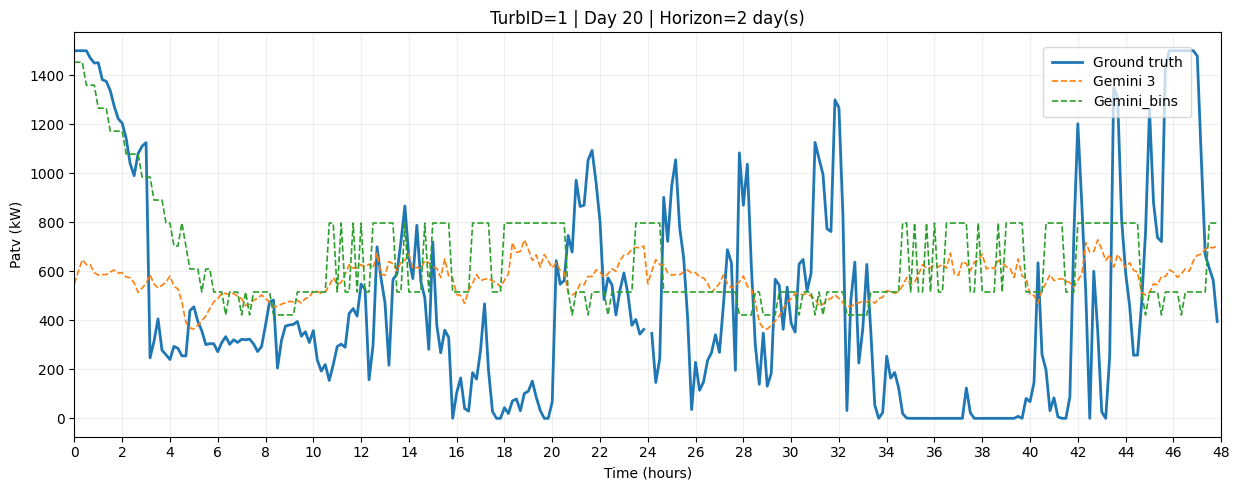

(<Figure size 1250x500 with 1 Axes>,
 <Axes: title={'center': 'TurbID=1 | Day 20 | Horizon=2 day(s)'}, xlabel='Time (hours)', ylabel='Patv (kW)'>)

In [6]:
plot_multi_predictions_vs_ground_truth(
    data_csv=DATA,
    pred_csv_paths=[
        r"llm_outputs-2Days/gemini3.csv",
        r"C:\Users\wahab\OneDrive\UCSD\ECE285\Project\Manual work\Trial 1\After_midway\Bins\gemini_16_bins_wspd_power_288pertime_decoded.csv",
        ],
    labels=["Gemini 3", "Gemini_bins"],
    turb_id=Turb_ID,
    forecast_day=forecast_day,
    horizon_days=2,
    pred_col="Patv_pred",
)